In [14]:
import sys
sys.path.append("..")
%run "../moduli.py"

Funzione Teorica
$$A(\omega) = \frac{1}{\sqrt{ (1 - \frac{\omega^2}{\Omega^2})^2 + \frac{1}{Q^2}\frac{\omega^2}{\Omega^2}}}$$

con $ \omega = 2 \pi f$.

In [15]:
offset = True

Con offset

In [16]:
if offset:
    def modello(par, f):  # f in Hz
        Omega, Q, area, x_off, y_off = par
        omega = 2 * np.pi * (f + x_off)
        return area / np.sqrt(
            (1 - (omega**2 / Omega**2))**2 +
            (1 / Q**2) * (omega**2 / Omega**2)
        ) + y_off

    param_labels = ["\\Omega", "Q", "Area", "f_{off}", "A_{off}"]

    beta0 = [2*np.pi*70000, 3, 1, 1, 1]

Senza offset

In [17]:
if not offset:
    def modello(par, f):  # f in Hz
        Omega, Q, area = par
        omega = 2 * np.pi * f
        return area / np.sqrt(
            (1 - (omega**2 / Omega**2))**2 +
            (1 / Q**2) * (omega**2 / Omega**2)
        )

    param_labels = ["\\Omega", "Q", "Area"]

    beta0 = [2*np.pi*70000, 3, 1]

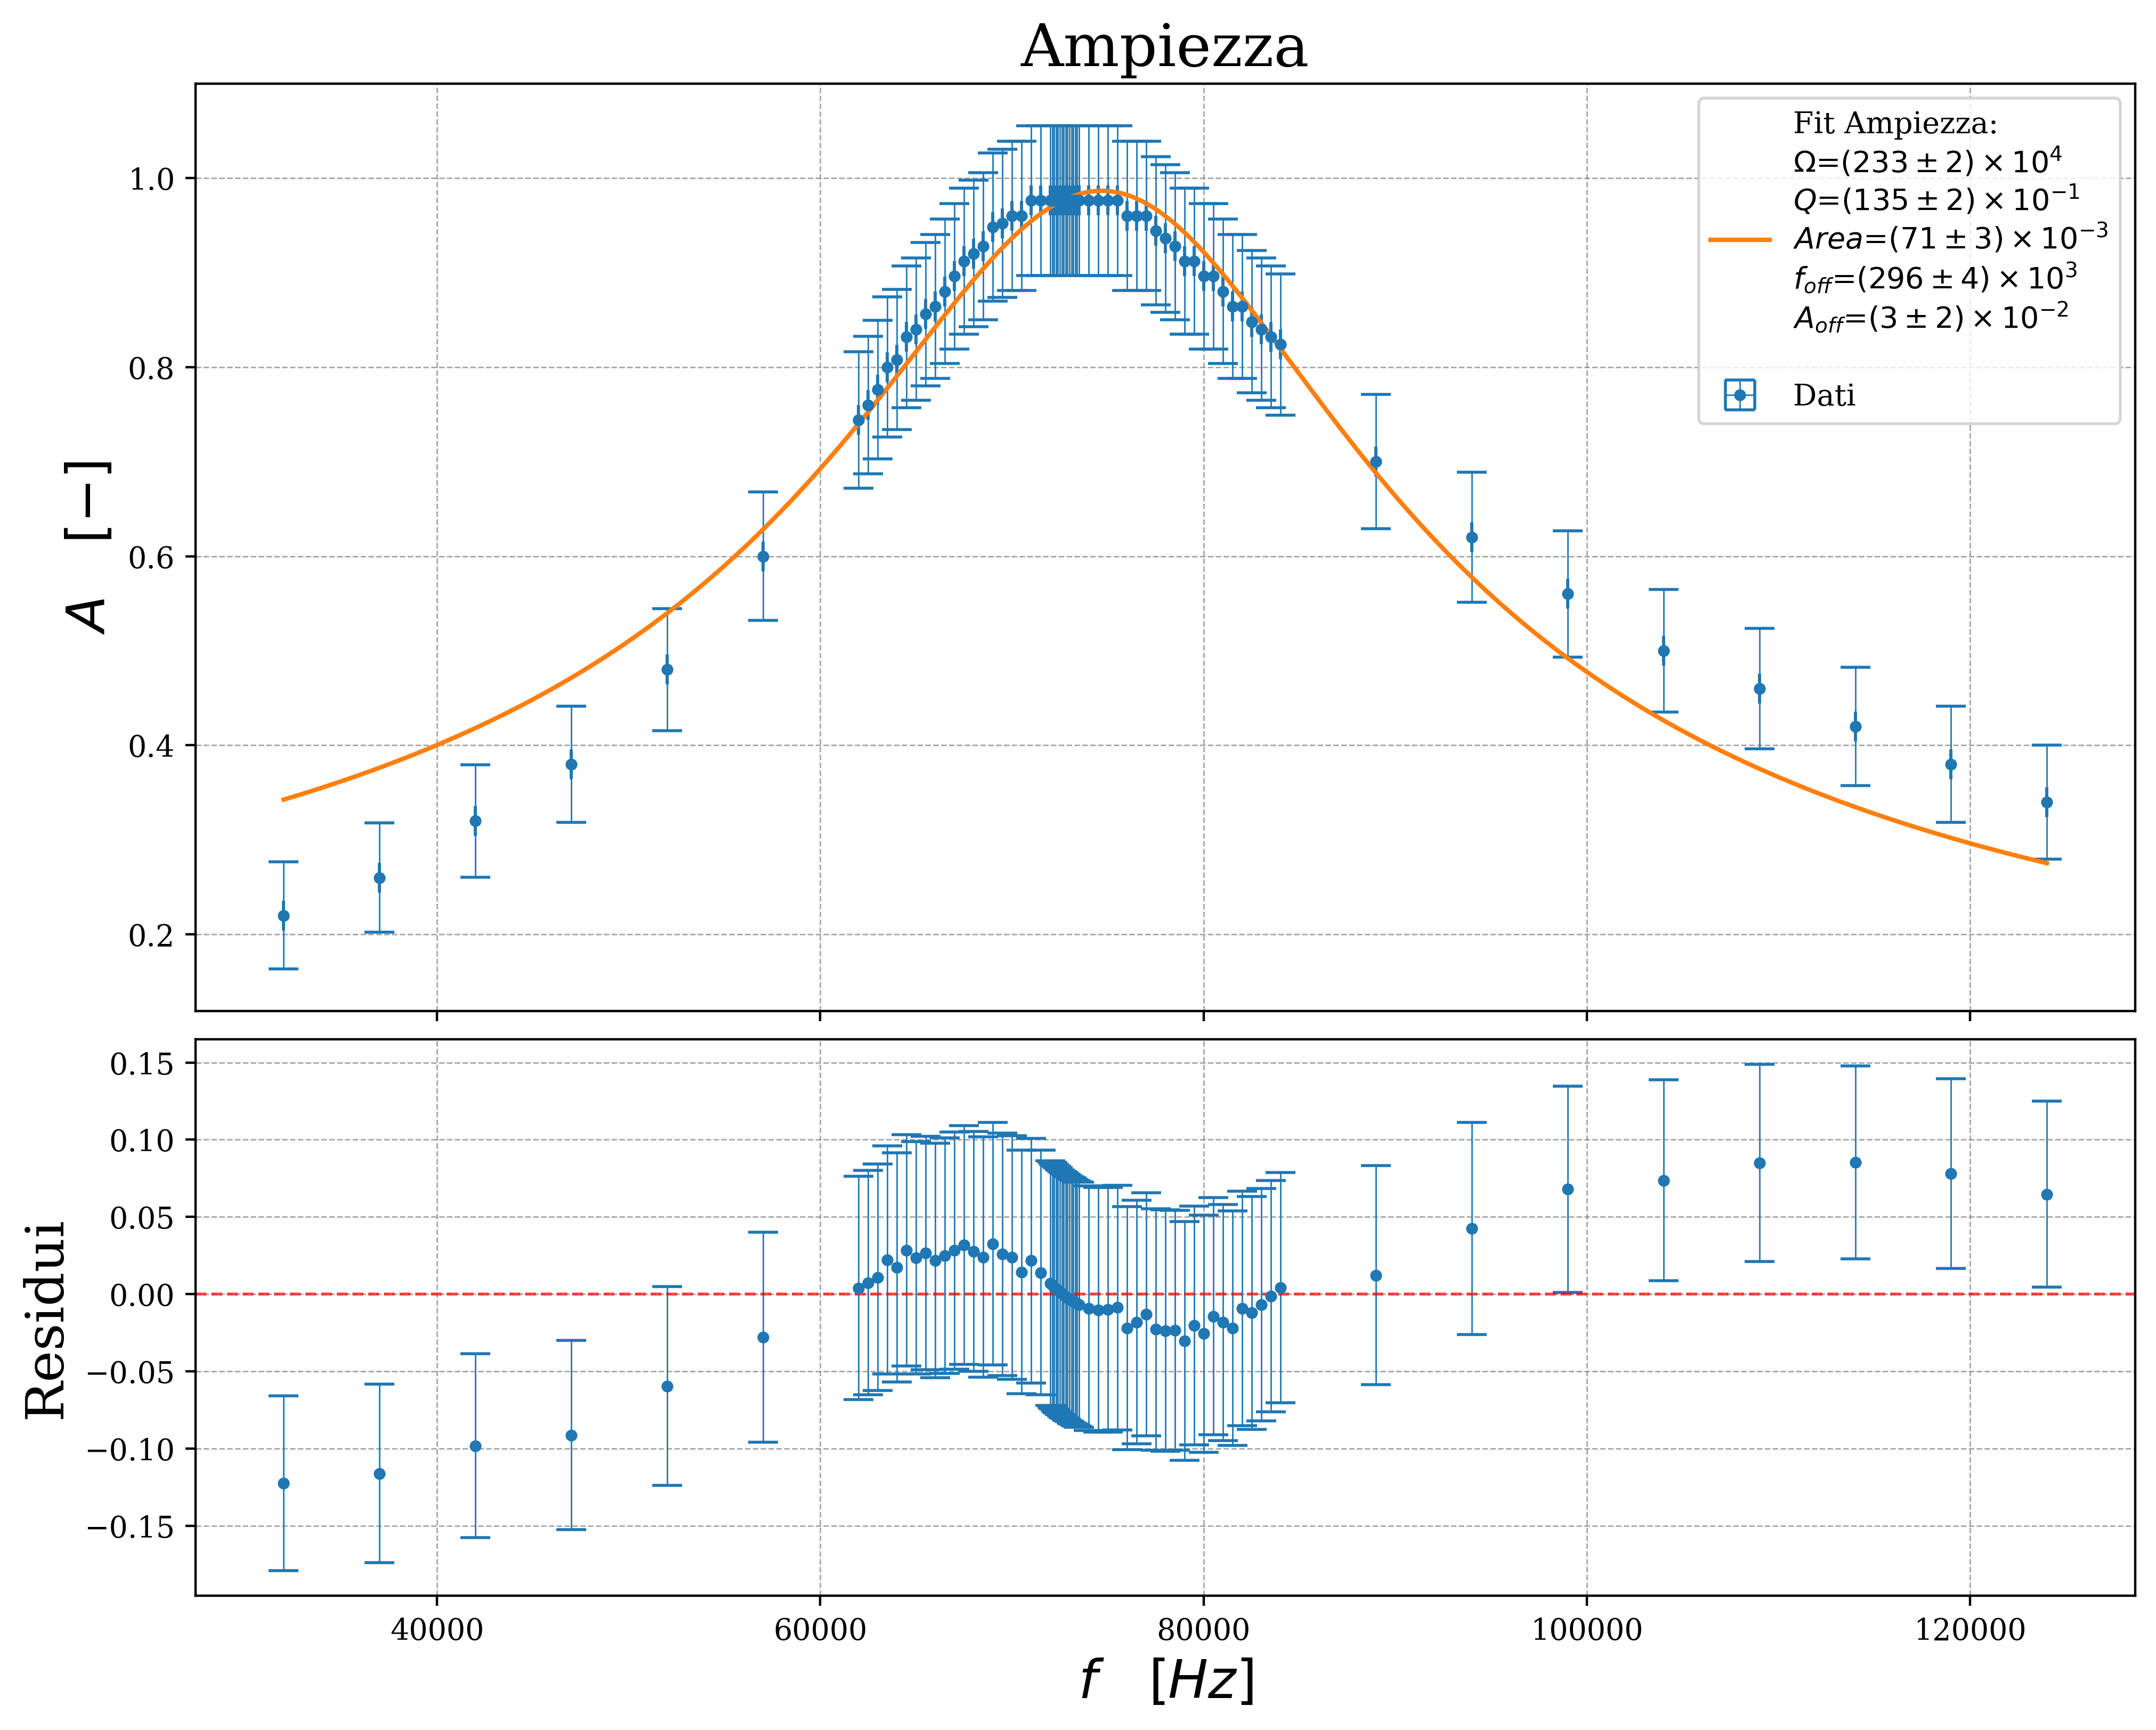

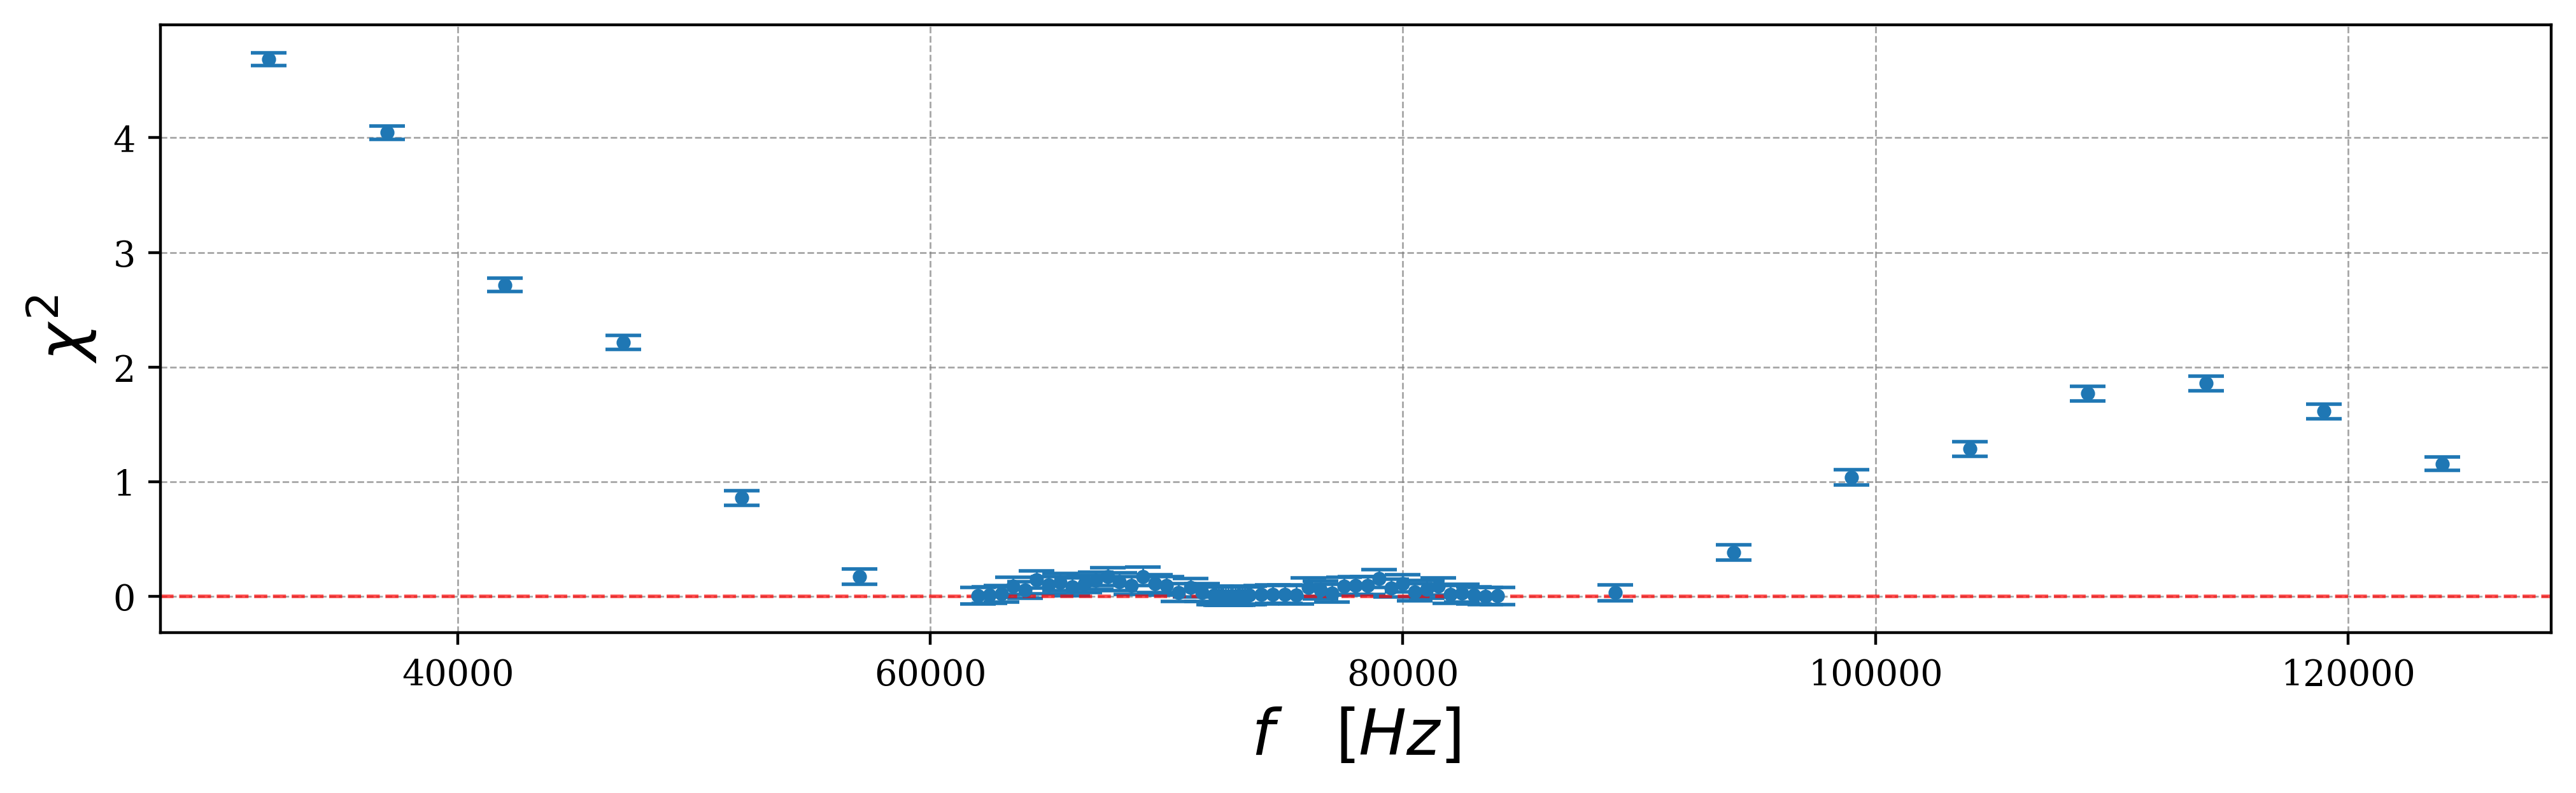

In [21]:
analisi = analizza("ampiezza", modello, param_labels, beta0, legenda_fontsize = 10)

In [19]:
print(analisi)

Parametri regressione :
2334750.656198841 ± 21904.682650268238
13.493310575335574 ± 0.2052916839577754
0.07053932183557002 ± 0.002534777079649503
296392.7435938296 ± 3522.588523759701
0.033897215180864984 ± 0.02155822783711011

Somma residui :
0.0937
Somma chi quadri e chi ridotto :
26.6789
0.4042



In [20]:
par = analisi.anal[0]
spar = analisi.anal[1]

parametri_profilazione = [[par[0], par[1], par[2]], [spar[0], spar[1], spar[2]]]
parametri_offset = [par[3], par[4]]
parametri = [parametri_profilazione, parametri_offset]
let.esporta_pickle(parametri, "ampiezza.pkl")